# Module 1

- Class limits and boundaries  
- Frequency, cumulative frequency, relative frequency, cumulative relative frequency  
- Frequency polygons and histograms  
- Measures of central tendency (mean, median, mode)  
- Measures of dispersion (range, variance, standard deviation, IQR, coefficient of variation)  
- Grouped and ungrouped data (including grouped formulas)  
- Random variables (discrete & continuous)  
- Bernoulli trials & binomial distribution  
- Acceptance sampling and operating characteristic (OC) curves  
- Normal distribution  
- Poisson distribution  
- Hypergeometric distribution  
- Exponential distribution



## Setup and Synthetic Data
We'll import common libraries and generate a small synthetic dataset to use throughout the notebook.


In [17]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility
rng = np.random.default_rng(seed=42)

# Create a synthetic dataset: e.g., test scores (0-100) with a slight normal shape
scores = np.clip(rng.normal(loc=72, scale=12, size=200).round(), 0, 100).astype(int)

# A DataFrame for convenience
df = pd.DataFrame({'score': scores})

df.head()

,score
0,76
1,60
2,81
3,83
4,49
...,...
195,61
196,80
197,67
198,72


## Class Limits and Boundaries

When data are recorded in whole numbers (like integer scores), **class boundaries** often extend by ±0.5 around the **class limits** to avoid gaps between classes.

Below we choose class width = 10 and build classes from 0 to 100. We compute:
- Class limits (e.g., 50–59)
- Class boundaries (e.g., 49.5–59.5)
- Frequency (count per class)
- Relative frequency (proportion per class)
- Cumulative frequency (running total)
- Cumulative relative frequency (running proportion)


In [2]:
# Define class limits (width=10) from 0 to 100 inclusively
class_limits = [(i, i+9) for i in range(0, 100, 10)]  # (lower, upper) as integer limits

# Class boundaries extend by 0.5 on each side (for integer recorded data)
class_boundaries = [(low-0.5, high+0.5) for (low, high) in class_limits]

# Prepare bins using boundaries for accurate histogram/frequency allocation
bins = [b[0] for b in class_boundaries] + [class_boundaries[-1][1]]

# Cut scores into these bins
cats = pd.cut(df['score'], bins=bins, right=True, include_lowest=True)

freq = cats.value_counts().sort_index()
rel_freq = (freq / freq.sum()).round(4)
cum_freq = freq.cumsum()
cum_rel_freq = rel_freq.cumsum().round(4)

freq_table = pd.DataFrame({
    'Class Limits': [f"{low}-{high}" for (low, high) in class_limits],
    'Class Boundaries': [f"{low:.1f}-{high:.1f}" for (low, high) in class_boundaries],
    'Frequency': freq.values,
    'Relative Frequency': rel_freq.values,
    'Cumulative Frequency': cum_freq.values,
    'Cumulative Relative Frequency': cum_rel_freq.values
})

freq_table

,Class Limits,Class Boundaries,Frequency,Relative Frequency,Cumulative Frequency,Cumulative Relative Frequency
0,0-9,-0.5-9.5,0,0.0000,0,0.0000
1,10-19,9.5-19.5,0,0.0000,0,0.0000
2,20-29,19.5-29.5,0,0.0000,0,0.0000
3,30-39,29.5-39.5,0,0.0000,0,0.0000
4,40-49,39.5-49.5,2,0.0101,2,0.0101
5,50-59,49.5-59.5,21,0.1055,23,0.1156
6,60-69,59.5-69.5,63,0.3166,86,0.4322
7,70-79,69.5-79.5,67,0.3367,153,0.7689
8,80-89,79.5-89.5,34,0.1709,187,0.9398
9,90-99,89.5-99.5,12,0.0603,199,1.0001


## Frequency Polygon and Histogram
A **histogram** shows the distribution using contiguous bars. A **frequency polygon** connects points at each class midpoint with lines.


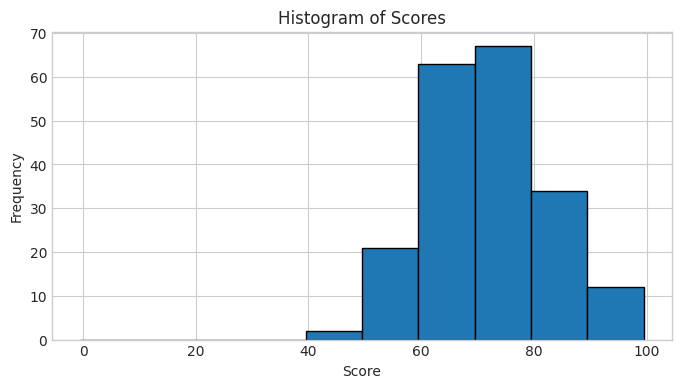

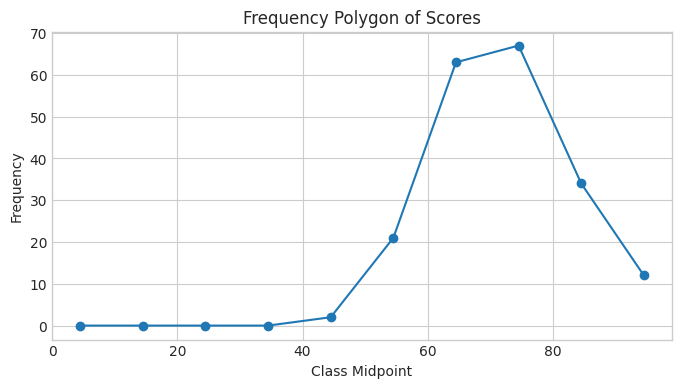

In [3]:
# Histogram using the same bins
plt.figure(figsize=(8, 4))
plt.hist(df['score'], bins=bins, edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

# Frequency polygon: compute midpoints and plot line through frequencies
midpoints = np.array([(low + high)/2 for (low, high) in class_limits])
plt.figure(figsize=(8, 4))
plt.plot(midpoints, freq.values, marker='o')
plt.title('Frequency Polygon of Scores')
plt.xlabel('Class Midpoint')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Measures of Central Tendency
We compute **mean**, **median**, and **mode** for the (ungrouped) raw data.


In [4]:
mean_raw = df['score'].mean()
median_raw = df['score'].median()
# Pandas mode can return multiple values; take them all
modes_raw = df['score'].mode().tolist()

print(f"Mean (ungrouped): {mean_raw:.2f}")
print(f"Median (ungrouped): {median_raw:.2f}")
print(f"Mode(s) (ungrouped): {modes_raw}")

Mean (ungrouped): 71.64
Median (ungrouped): 71.00
Mode(s) (ungrouped): [67]


### Grouped Data — Approximate Mean and Variance
For grouped data, we use **class midpoints** (\(m_i\)) and **frequencies** (\(f_i\):

- Grouped mean: 
\[ 
ar{x}_g = rac{\sum f_i m_i}{\sum f_i} 
\]

- Grouped variance (sample): 
\[ 
 s_g^2 = rac{\sum f_i (m_i - ar{x}_g)^2}{\sum f_i - 1} 
\]


In [5]:
# Grouped mean using midpoints and class frequencies
f = freq.values
m = midpoints
N = f.sum()
mean_grouped = np.sum(f * m) / N

# Grouped variance (sample)
var_grouped = np.sum(f * (m - mean_grouped)**2) / (N - 1)
std_grouped = math.sqrt(var_grouped)

print(f"Grouped mean: {mean_grouped:.2f}")
print(f"Grouped variance (sample): {var_grouped:.2f}")
print(f"Grouped std dev (sample): {std_grouped:.2f}")

Grouped mean: 71.84
Grouped variance (sample): 117.62
Grouped std dev (sample): 10.85


## Measures of Dispersion
We compute **range**, **variance**, **standard deviation**, **interquartile range (IQR)**, and **coefficient of variation (CV)** for ungrouped data.


In [6]:
range_raw = df['score'].max() - df['score'].min()
var_raw = df['score'].var(ddof=1)  # sample variance
std_raw = df['score'].std(ddof=1)
q1, q3 = df['score'].quantile([0.25, 0.75])
iqr_raw = q3 - q1
cv_raw = std_raw / mean_raw

print(f"Range: {range_raw:.2f}")
print(f"Variance (sample): {var_raw:.2f}")
print(f"Std dev (sample): {std_raw:.2f}")
print(f"IQR: {iqr_raw:.2f}")
print(f"Coefficient of variation: {cv_raw:.3f}")

Range: 54.00
Variance (sample): 110.36
Std dev (sample): 10.51
IQR: 14.25
Coefficient of variation: 0.147


## Grouped vs. Ungrouped Data
- **Ungrouped**: uses all raw values directly.  
- **Grouped**: summarizes data into classes; computations use midpoints and frequencies.

Below we compare the ungrouped mean/std to the grouped approximations.


In [7]:
print(f"Ungrouped mean: {mean_raw:.2f}, Grouped mean: {mean_grouped:.2f}")
print(f"Ungrouped std dev: {std_raw:.2f}, Grouped std dev: {std_grouped:.2f}")

Ungrouped mean: 71.64, Grouped mean: 71.84
Ungrouped std dev: 10.51, Grouped std dev: 10.85


## Random Variables
A **random variable** maps outcomes to numbers:
- **Discrete** (e.g., number of defects per item)
- **Continuous** (e.g., time to failure)

We'll construct a discrete RV with a custom distribution and a continuous RV sampled from a normal distribution.


Discrete RV: E[X] = 0.750, Var(X) = 0.788
Continuous RV sample: mean≈4.917, std≈2.046


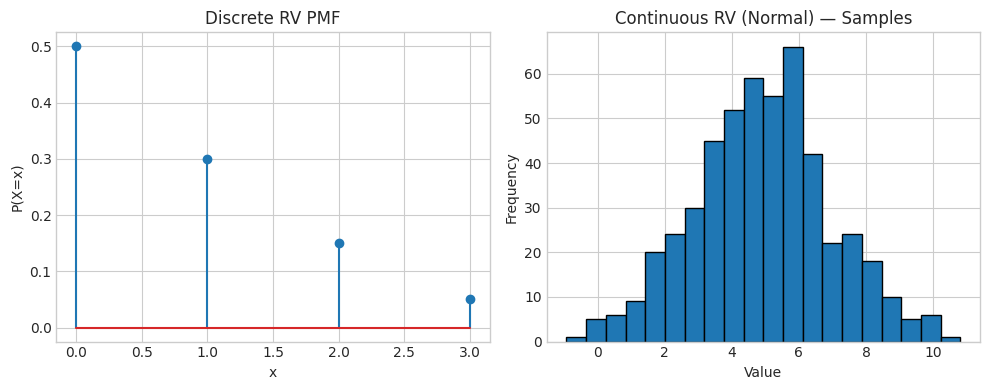

In [8]:
# Discrete RV: outcomes {0,1,2,3} with custom probabilities
values = np.array([0, 1, 2, 3])
probs = np.array([0.5, 0.3, 0.15, 0.05])
assert abs(probs.sum() - 1) < 1e-9

# Expected value and variance for discrete RV
E = np.sum(values * probs)
Var = np.sum((values - E)**2 * probs)
print(f"Discrete RV: E[X] = {E:.3f}, Var(X) = {Var:.3f}")

# Continuous RV: sample from Normal(mu=5, sigma=2)
mu, sigma = 5, 2
cont_samples = rng.normal(mu, sigma, size=500)
print(f"Continuous RV sample: mean≈{cont_samples.mean():.3f}, std≈{cont_samples.std(ddof=1):.3f}")

# Plot discrete PMF and continuous histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
#ax[0].stem(values, probs, use_line_collection=True)
ax[0].stem(values, probs)
ax[0].set_title('Discrete RV PMF')
ax[0].set_xlabel('x')
ax[0].set_ylabel('P(X=x)')

ax[1].hist(cont_samples, bins=20, edgecolor='black')
ax[1].set_title('Continuous RV (Normal) — Samples')
ax[1].set_xlabel('Value')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Bernoulli Trials and Binomial Distribution
- **Bernoulli trial**: a single experiment with outcomes success (1) or failure (0) at probability \(p\).  
- **Binomial**: number of successes in \(n\) independent Bernoulli trials with probability \(p\).

We implement the Binomial PMF \(\mathrm{P}(X=k) = inom{n}{k} p^k (1-p)^{n-k}\) and compare theory to simulation.


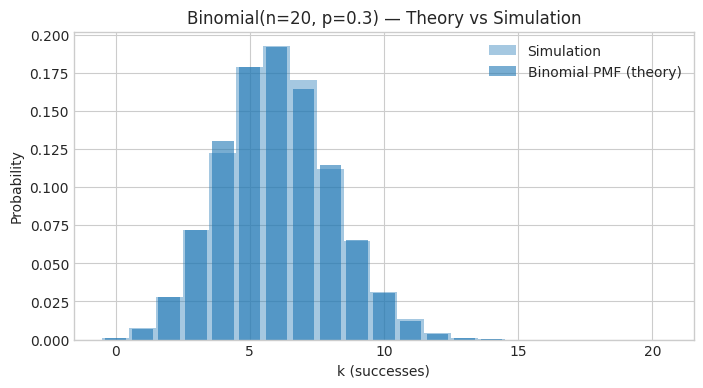

Mean (np): 6.000, Variance (np(1-p)): 4.200


In [9]:
def binom_pmf(k, n, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

n, p = 20, 0.3
k_vals = np.arange(0, n+1)
pmf_vals = np.array([binom_pmf(k, n, p) for k in k_vals])

# Simulation
trials = 10000
sim_counts = (rng.random((trials, n)) < p).sum(axis=1)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(k_vals, pmf_vals, alpha=0.6, label='Binomial PMF (theory)')
plt.hist(sim_counts, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.4, label='Simulation')
plt.title(f'Binomial(n={n}, p={p}) — Theory vs Simulation')
plt.xlabel('k (successes)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# Mean and variance
mean_bin = n * p
var_bin = n * p * (1-p)
print(f"Mean (np): {mean_bin:.3f}, Variance (np(1-p)): {var_bin:.3f}")

## Acceptance Sampling and Operating Characteristic (OC) Curves
In a single-sampling plan with sample size \(n\) and acceptance number \(c\), the probability of **accepting** a lot with fraction defective \(p\) is:
\[ P_{	ext{accept}}(p) = \sum_{x=0}^{c} inom{n}{x} p^x (1-p)^{n-x} \]
This is the lower tail of a binomial distribution.

We plot the **OC curve** for a plan with \(n=50\) and \(c=1\).

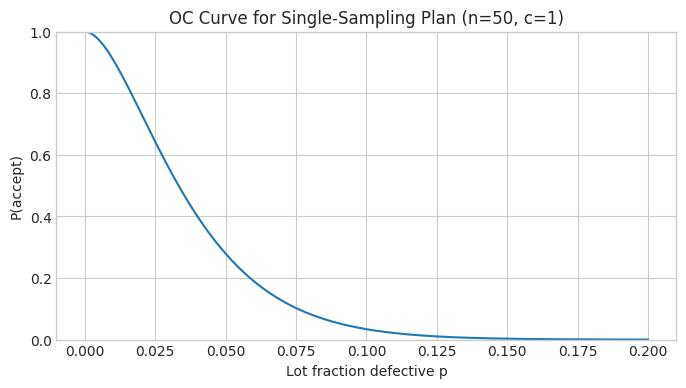

At AQL=1.00%, P(accept)≈0.911; at LQL=10.00%, P(accept)≈0.034


In [10]:
def p_accept_binomial(p, n=50, c=1):
    return sum(binom_pmf(x, n, p) for x in range(0, c+1))

n, c = 50, 1
p_grid = np.linspace(0, 0.2, 201)
Pacc = np.array([p_accept_binomial(p, n=n, c=c) for p in p_grid])

plt.figure(figsize=(8, 4))
plt.plot(p_grid, Pacc)
plt.title(f'OC Curve for Single-Sampling Plan (n={n}, c={c})')
plt.xlabel('Lot fraction defective p')
plt.ylabel('P(accept)')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Example: AQL/LQL markers (illustrative)
# Suppose AQL=0.01 and LQL=0.10
AQL, LQL = 0.01, 0.10
Pacc_AQL = p_accept_binomial(AQL, n=n, c=c)
Pacc_LQL = p_accept_binomial(LQL, n=n, c=c)
print(f"At AQL={AQL:.2%}, P(accept)≈{Pacc_AQL:.3f}; at LQL={LQL:.2%}, P(accept)≈{Pacc_LQL:.3f}")

## Normal Distribution
We implement the Normal PDF and CDF (using the error function) and visualize them.


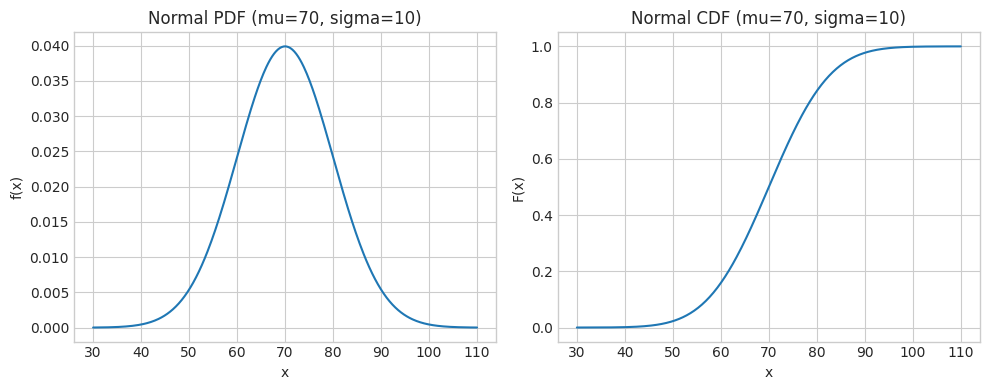

P(60 ≤ X ≤ 80) for N(70,10^2) ≈ 0.683


In [11]:
def normal_pdf(x, mu=0.0, sigma=1.0):
    return (1/(sigma*math.sqrt(2*math.pi))) * math.exp(-0.5 * ((x-mu)/sigma)**2)

# Normal CDF via error function
# Phi(x) = 0.5 * [1 + erf((x - mu)/(sigma*sqrt(2)))]

def normal_cdf(x, mu=0.0, sigma=1.0):
    return 0.5 * (1 + math.erf((x - mu) / (sigma * math.sqrt(2))))

mu, sigma = 70, 10
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf_vals = np.array([normal_pdf(t, mu, sigma) for t in x])
cdf_vals = np.array([normal_cdf(t, mu, sigma) for t in x])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x, pdf_vals)
ax[0].set_title(f'Normal PDF (mu={mu}, sigma={sigma})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')

ax[1].plot(x, cdf_vals)
ax[1].set_title(f'Normal CDF (mu={mu}, sigma={sigma})')
ax[1].set_xlabel('x')
ax[1].set_ylabel('F(x)')
plt.tight_layout()
plt.show()

# Example probabilities: P(60 <= X <= 80)
lo, hi = 60, 80
p_interval = normal_cdf(hi, mu, sigma) - normal_cdf(lo, mu, sigma)
print(f"P({lo} ≤ X ≤ {hi}) for N({mu},{sigma}^2) ≈ {p_interval:.3f}")

## Poisson Distribution
The Poisson PMF with rate \(\lambda\) is \(P(X=k) = e^{-\lambda} \lambda^k / k!\). We plot the PMF and compare to simulated counts.


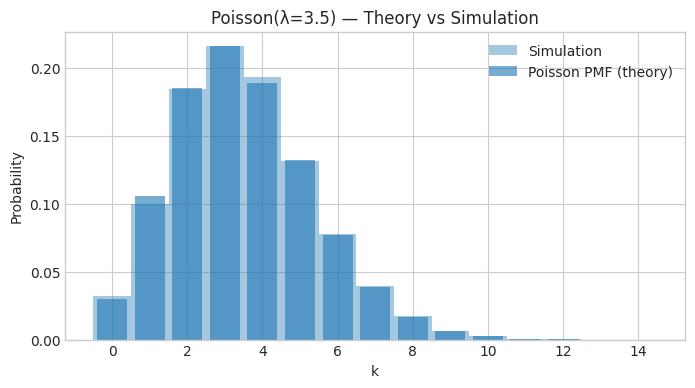

Mean≈3.500, Variance≈3.500 for Poisson(λ)


In [12]:
def poisson_pmf(k, lam):
    return math.exp(-lam) * (lam**k) / math.factorial(k)

lam = 3.5
k_vals = np.arange(0, 15)
pmf_vals = np.array([poisson_pmf(k, lam) for k in k_vals])

# Simulate Poisson counts
sim_counts = rng.poisson(lam=lam, size=10000)

plt.figure(figsize=(8, 4))
plt.bar(k_vals, pmf_vals, alpha=0.6, label='Poisson PMF (theory)')
plt.hist(sim_counts, bins=np.arange(-0.5, k_vals[-1]+1.5, 1), density=True, alpha=0.4, label='Simulation')
plt.title(f'Poisson(λ={lam}) — Theory vs Simulation')
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()

print(f"Mean≈{lam:.3f}, Variance≈{lam:.3f} for Poisson(λ)")

## Hypergeometric Distribution
Sampling **without replacement** from a finite population of size \(N\) with \(K\) successes (defectives), drawing \(n\) items:
\[ P(X=k) = rac{inom{K}{k} inom{N-K}{n-k}}{inom{N}{n}} \]
We plot the PMF.


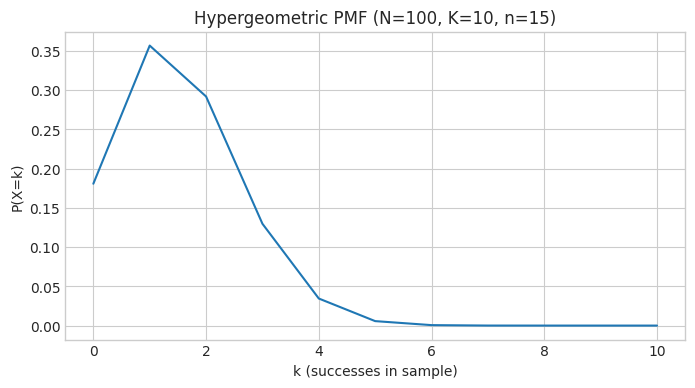

Mean: 1.500, Variance: 1.159


In [20]:
def comb(n, r):
    return math.comb(n, r)

def hypergeo_pmf(k, N, K, n):
    return (comb(K, k) * comb(N-K, n-k)) / comb(N, n)

N, K, n = 100, 10, 15
k_support = np.arange(max(0, n - (N-K)), min(n, K) + 1)
pmf_vals = np.array([hypergeo_pmf(k, N, K, n) for k in k_support])

plt.figure(figsize=(8, 4))
#plt.stem(k_support, pmf_vals, use_line_collection=True)

#plt.stem(k_support, pmf_vals)
plt.plot(k_support, pmf_vals)
plt.title(f'Hypergeometric PMF (N={N}, K={K}, n={n})')
plt.xlabel('k (successes in sample)')
plt.ylabel('P(X=k)')
plt.show()

# Mean and variance
mean_h = n * (K / N)
var_h = n * (K / N) * (1 - K / N) * ((N - n) / (N - 1))
print(f"Mean: {mean_h:.3f}, Variance: {var_h:.3f}")

## Exponential Distribution
The Exponential PDF with rate \(\lambda\) is \(f(x) = \lambda e^{-\lambda x}\) for \(x \ge 0\). We illustrate the PDF, CDF, and the **memoryless** property.


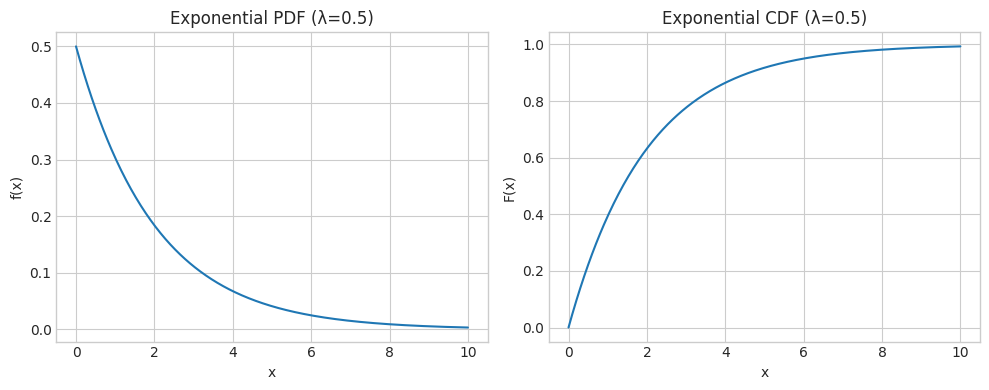

P(X > s+t | X > s)≈0.226,  P(X > t)≈0.229


In [19]:
def exponential_pdf(x, lam):
    return lam * np.exp(-lam * x)

def exponential_cdf(x, lam):
    return 1 - np.exp(-lam * x)

lam = 0.5
x = np.linspace(0, 10, 400)
pdf_vals = exponential_pdf(x, lam)
cdf_vals = exponential_cdf(x, lam)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x, pdf_vals)
ax[0].set_title(f'Exponential PDF (λ={lam})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')

ax[1].plot(x, cdf_vals)
ax[1].set_title(f'Exponential CDF (λ={lam})')
ax[1].set_xlabel('x')
ax[1].set_ylabel('F(x)')
plt.tight_layout()
plt.show()

# Simulation to illustrate memoryless property: P(X > s + t | X > s) = P(X > t)
s, t = 2.0, 3.0
samples = rng.exponential(scale=1/lam, size=20000)
prop_cond = np.mean(samples[samples > s] > s + t)
prop_uncond = np.mean(samples > t)
print(f"P(X > s+t | X > s)≈{prop_cond:.3f},  P(X > t)≈{prop_uncond:.3f}")

## Wrap-up
This notebook demonstrated core statistical concepts with Python.
- Frequency tables, histograms, and frequency polygons
- Central tendency and dispersion (grouped & ungrouped)
- Random variables and common distributions (Binomial, Normal, Poisson, Hypergeometric, Exponential)
- Acceptance sampling and OC curves

Feel free to modify parameters (e.g., bin widths, distribution parameters) and re-run cells to explore behavior.
